In [4]:
!pip install --upgrade numpy scipy scikit-learn pandas seaborn

  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached pandas-3.0.2-cp312-cp312-win_amd64.whl.metadata (19 kB)
Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl (12.3 MB)
Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl (36.5 MB)
Using cached pandas-3.0.2-cp312-cp312-win_amd64.whl (9.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:
      Successfully uninstalled pandas-2.3.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.4 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.2 which is incompatible.


In [1]:
import os
import requests
import tarfile

# 1. URL officielle du dataset IMDb
url = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filename = "aclImdb_v1.tar.gz"

# 2. Téléchargement du fichier
if not os.path.exists(filename):
    print("Téléchargement en cours... (environ 80 Mo)")
    response = requests.get(url, stream=True)
    with open(filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=1024):
            if chunk:
                f.write(chunk)
    print("Téléchargement terminé.")

# 3. Extraction de l'archive
if not os.path.exists('aclImdb'):
    print("Extraction des fichiers...")
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()
    print("Extraction terminée.")

# 4. Mise à jour du chemin pour votre script
imdb_dir = os.path.join(os.getcwd(), 'aclImdb')
print(f"Répertoire des données : {imdb_dir}")

Répertoire des données : c:\Users\awa\Desktop\Cours_MSDA\UGB\Sujet_1\aclImdb


Classification de critiques de films IMDb avec embeddings GloVe et LSTM bidirectionnel
Améliorations :
- Utilisation de 80% des données pour l'entraînement
- Nettoyage du texte (HTML, ponctuation, stop words optionnels)
- Définition dynamique de maxlen basée sur la distribution des longueurs
- Architecture : Embedding pré-entraîné + LSTM bidirectionnel + Dropout
- Fine-tuning progressif des embeddings
- Sauvegarde du modèle ET du tokenizer
- Évaluation avec matrice de confusion et courbes de perte
"""

In [3]:
!pip install tensorflow

  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.6 MB 985.5 kB/s eta 0:05:56
   ---------------------------------------- 0.8/350.6 MB 987.4 kB/s eta 0:05:55
   ---------------------------------------- 1.0/350.6 MB 1.0 MB/s eta 0:05:41
   ---------------------------------------- 1.3/350.6 MB 1.1 MB/s eta 0:05:29
   ---------------------------------------- 1.6/350.6 MB 1.1 MB/s eta 0:05:29
   ---------------------------------------- 1.6/350.6 MB 1.1 MB/s eta 0:05:29
   ---------------------------------------- 1.6/350.6 MB 1.1 MB/s eta 0:05:29
   ----------------------------------------

In [4]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model


In [5]:
import os

# ---------------------------
# 2. Paramètres globaux (ADAPTÉS)
# ---------------------------

# On pointe vers le dossier local extrait par votre code précédent
imdb_dir = os.path.join(os.getcwd(), 'aclImdb') 

max_words = 10000     # Nombre de mots à conserver
embedding_dim = 100   # Dimension GloVe
batch_size = 64
epochs = 20
validation_split = 0.2

In [7]:
# ---------------------------
# 3. Chargement et nettoyage des données
# ---------------------------
def clean_text(text):
    """Nettoie une critique : supprime les balises HTML, ponctuation, chiffres, etc."""
    text = re.sub(r'<br\s*/?>', ' ', text)       # supprime <br /> et <br>
    text = re.sub(r'[^a-zA-Z\s]', '', text)      # supprime tout sauf lettres et espaces
    text = re.sub(r'\s+', ' ', text)             # réduit les espaces multiples
    return text.lower().strip()


In [8]:
def load_data(data_dir):
    """Charge les données du répertoire train ou test, nettoie les textes."""
    labels = []
    texts = []
    for label_type in ['neg', 'pos']:
        dir_name = os.path.join(data_dir, label_type)
        for fname in os.listdir(dir_name):
            if fname.endswith('.txt'):
                with open(os.path.join(dir_name, fname), encoding='utf-8') as f:
                    text = f.read()
                texts.append(clean_text(text))
                labels.append(0 if label_type == 'neg' else 1)
    return texts, np.array(labels)

print("Chargement des données d'entraînement...")
train_texts, train_labels = load_data(os.path.join(imdb_dir, 'train'))
print(f"Nombre de critiques d'entraînement : {len(train_texts)}")


Chargement des données d'entraînement...
Nombre de critiques d'entraînement : 25000


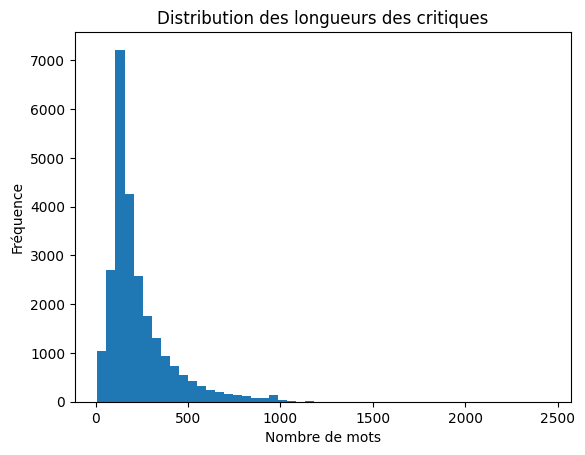

In [9]:
# ---------------------------
# 4. Détermination de maxlen basée sur la distribution
# ---------------------------
# Calcul des longueurs des critiques (en mots)
lengths = [len(text.split()) for text in train_texts]
plt.hist(lengths, bins=50)
plt.title('Distribution des longueurs des critiques')
plt.xlabel('Nombre de mots')
plt.ylabel('Fréquence')
plt.show()


In [10]:
# Choisir un seuil (par exemple 90e percentile)
maxlen = int(np.percentile(lengths, 90))
print(f"Longueur maximale choisie (90e percentile) : {maxlen} mots")


Longueur maximale choisie (90e percentile) : 450 mots


In [11]:
# ---------------------------
# 5. Tokenisation et conversion en séquences
# ---------------------------
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train_texts)
sequences = tokenizer.texts_to_sequences(train_texts)
word_index = tokenizer.word_index
print(f"Nombre de tokens uniques : {len(word_index)}")

# Padding des séquences
data = pad_sequences(sequences, maxlen=maxlen)


Nombre de tokens uniques : 108661


In [12]:
# ---------------------------
# 6. Division en entraînement / validation
# ---------------------------
x_train, x_val, y_train, y_val = train_test_split(
    data, train_labels, test_size=validation_split, random_state=42, stratify=train_labels
)
print(f"Taille entraînement : {x_train.shape}, validation : {x_val.shape}")



Taille entraînement : (20000, 450), validation : (5000, 450)


In [14]:
# ---------------------------
# 7. Téléchargement et chargement des embeddings GloVe
# ---------------------------
import zipfile
import requests

glove_file = 'glove.6B.100d.txt'
glove_zip = 'glove.6B.zip'
glove_url = 'https://nlp.stanford.edu/data/glove.6B.zip'

if not os.path.exists(glove_file):
    if not os.path.exists(glove_zip):
        print("Téléchargement GloVe en cours...")
        r = requests.get(glove_url, stream=True)
        r.raise_for_status()
        with open(glove_zip, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
        print("Téléchargement terminé.")

    print("Décompression GloVe...")
    with zipfile.ZipFile(glove_zip, 'r') as z:
        z.extract(glove_file)
    print("GloVe téléchargé et décompressé.")

if not os.path.exists(glove_file):
    raise FileNotFoundError(f"Impossible de trouver {glove_file} après téléchargement.")

embeddings_index = {}
with open(glove_file, encoding='utf-8') as f:
    for line in f:
        values = line.strip().split()
        if not values:
            continue
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
print(f"Nombre de vecteurs GloVe chargés : {len(embeddings_index)}")


Téléchargement GloVe en cours...
Téléchargement terminé.
Décompression GloVe...
GloVe téléchargé et décompressé.
Nombre de vecteurs GloVe chargés : 400000


In [15]:
# Construction de la matrice d'embedding
embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    if i < max_words:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [16]:
# ---------------------------
# 8. Construction du modèle avec LSTM bidirectionnel
# ---------------------------
model = Sequential()
model.add(Embedding(max_words, embedding_dim, input_length=maxlen, weights=[embedding_matrix], trainable=False))
model.add(Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


c:\Users\awa\anaconda3\envs\clean_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [17]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)



In [18]:
# ---------------------------
# 9. Entraînement initial (embedding gelé)
# ---------------------------
history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)



Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1160s 4s/step - accuracy: 0.5830 - loss: 0.6692 - val_accuracy: 0.6870 - val_loss: 0.5862 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1155s 4s/step - accuracy: 0.7265 - loss: 0.5678 - val_accuracy: 0.8048 - val_loss: 0.4443 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1114s 4s/step - accuracy: 0.7809 - loss: 0.4927 - val_accuracy: 0.8200 - val_loss: 0.4023 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1042s 3s/step - accuracy: 0.8023 - loss: 0.4481 - val_accuracy: 0.8348 - val_loss: 0.3779 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1667s 5s/step - accuracy: 0.8218 - loss: 0.4139 - val_accuracy: 0.8468 - val_loss: 0.3586 - learning_rate: 0.0010
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1541s 5s/step - accuracy: 0.8324 - loss: 0.3933 - val_accuracy: 0.8544 - val_loss: 0.3398 - learning_rate: 0.0010
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1085s 3s/step - accuracy: 0.8407 - l

In [19]:
# ---------------------------
# 10. Fine-tuning : dégeler l'embedding et continuer avec un petit learning rate
# ---------------------------
model.layers[0].trainable = True
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])  # learning rate plus faible (par défaut 1e-3)
# On peut aussi définir un LR plus petit : optimizer = tf.keras.optimizers.Adam(1e-5)
history_finetune = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=5,  # quelques époques supplémentaires
    validation_data=(x_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1424s 4s/step - accuracy: 0.8851 - loss: 0.2843 - val_accuracy: 0.8910 - val_loss: 0.2844 - learning_rate: 0.0010
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1394s 4s/step - accuracy: 0.9048 - loss: 0.2427 - val_accuracy: 0.8956 - val_loss: 0.2704 - learning_rate: 0.0010
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1330s 4s/step - accuracy: 0.9261 - loss: 0.2017 - val_accuracy: 0.8974 - val_loss: 0.2825 - learning_rate: 0.0010
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1363s 4s/step - accuracy: 0.9391 - loss: 0.1651 - val_accuracy: 0.8988 - val_loss: 0.3007 - learning_rate: 0.0010
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1347s 4s/step - accuracy: 0.9545 - loss: 0.1286 - val_accuracy: 0.9016 - val_loss: 0.3267 - learning_rate: 2.0000e-04


In [ ]:
# ---------------------------
# 11. Sauvegarde du modèle et du tokenizer pour une utilisation future
# ---------------------------
model.save('imdb_lstm_glove.h5')
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Modèle et tokenizer sauvegardés.")



Modèle et tokenizer sauvegardés.


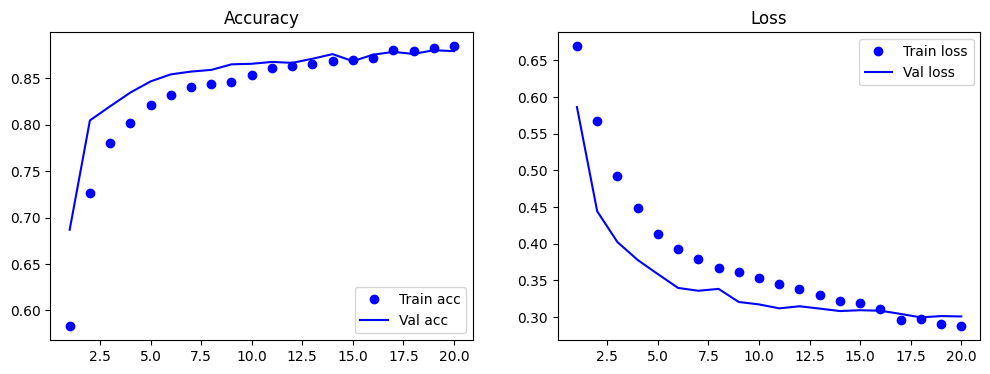

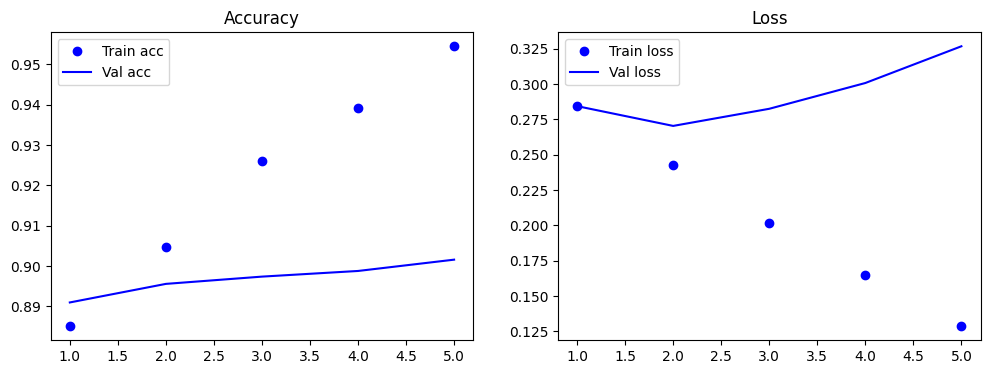

In [21]:
# ---------------------------
# 12. Visualisation des courbes d'apprentissage
# ---------------------------
def plot_history(hist):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, 'bo', label='Train acc')
    plt.plot(epochs_range, val_acc, 'b', label='Val acc')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, 'bo', label='Train loss')
    plt.plot(epochs_range, val_loss, 'b', label='Val loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

plot_history(history)
if 'history_finetune' in locals():
    plot_history(history_finetune)



Chargement des données de test...
Accuracy sur le test : 0.8987
782/782 ━━━━━━━━━━━━━━━━━━━━ 121s 148ms/step


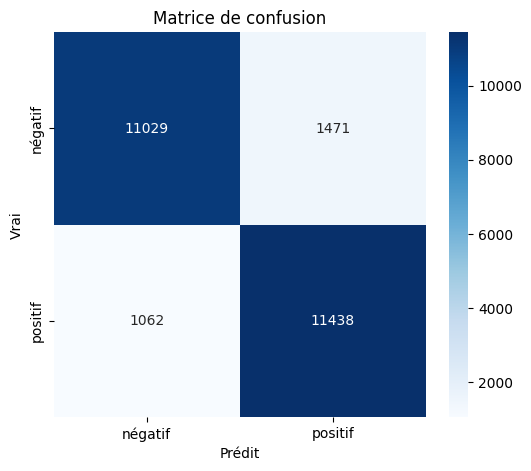


Rapport de classification :
              precision    recall  f1-score   support

     négatif       0.91      0.88      0.90     12500
     positif       0.89      0.92      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



In [22]:

# ---------------------------
# 13. Évaluation sur l'ensemble de test
# ---------------------------
print("Chargement des données de test...")
test_texts, test_labels = load_data(os.path.join(imdb_dir, 'test'))
test_sequences = tokenizer.texts_to_sequences(test_texts)
x_test = pad_sequences(test_sequences, maxlen=maxlen)
y_test = test_labels

# Évaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Accuracy sur le test : {test_acc:.4f}")

# Prédictions
y_pred = (model.predict(x_test) > 0.5).astype(int).flatten()

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['négatif', 'positif'], yticklabels=['négatif', 'positif'])
plt.ylabel('Vrai')
plt.xlabel('Prédit')
plt.title('Matrice de confusion')
plt.show()

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=['négatif', 'positif']))


In [23]:
# ---------------------------
# 14. Prédiction sur un nouveau texte
# ---------------------------
def predict_sentiment(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=maxlen)
    prob = model.predict(padded)[0][0]
    sentiment = "positif" if prob >= 0.5 else "négatif"
    return prob, sentiment

# Exemple
sample = "This is one of the first films I can remember, or maybe the first one. Exactly the beautiful kind of film than introduce a kid, sweetly, into the world of violence and addictions were we live. A little bit of Babe, Casino and Constantine, all this well mixed into a carton, and we get this. I don't know if its truly rated for kids, but I think it was very cool, very funny and interesting. I hate when a film (spescially a carton)can have a good end and its ruining because every character must have a happy end, even if it sounds weird (Im not a bitter person).But this was OK, he simply goes heaven and they let it in that way.<br /><br />All this is just a critic, Its a good movie an something new. very touching and I gotta go"
prob, sentiment = predict_sentiment(sample)
print(f"Texte : {sample[:200]}...")
print(f"Probabilité de positivité : {prob:.4f} -> Sentiment : {sentiment}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
Texte : This is one of the first films I can remember, or maybe the first one. Exactly the beautiful kind of film than introduce a kid, sweetly, into the world of violence and addictions were we live. A littl...
Probabilité de positivité : 0.9899 -> Sentiment : positif
